# Facial Keypoint Detection — Evaluación: CNN Baseline con QAT

## 1. Imports

In [1]:
#%pip install torch torchvision

import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.ao.quantization as tq
from torch.utils.data import Dataset, DataLoader, random_split


def pick_eval_device():
    if torch.cuda.is_available():
        try:
            t = torch.zeros(256, 3, 96, 96, device='cuda')  
            del t
            torch.cuda.empty_cache()
            print(f'Usando CUDA (NVIDIA GPU): {torch.cuda.get_device_name(0)}')
            return torch.device('cuda')
        except RuntimeError as e:
            torch.cuda.empty_cache()
            print('GPU ocupada/sin memoria -> uso CPU. (' + str(e).splitlines()[0] + ')')
    else:
        print('CUDA no disponible, usando CPU.')
    return torch.device('cpu')

device = pick_eval_device()


CUDA no disponible, usando CPU.


## 2. Configuración

In [2]:
DATA_DIR       = r'C:\Users\perec\Desktop\Deep_Learning'
IMAGES_PATH    = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
MODEL_PATH     = os.path.join(DATA_DIR, 'best_qat_cnn.pth')
LOSSES_PATH    = os.path.join(DATA_DIR, 'training_losses_qat.pkl')

IMG_SIZE   = 96
BATCH_SIZE = 64
SEED       = 42
N_SHOW     = 8

QAT_BACKEND = 'fbgemm' if 'fbgemm' in torch.backends.quantized.supported_engines else 'qnnpack'
torch.backends.quantized.engine = QAT_BACKEND
print(f'QAT_BACKEND: {QAT_BACKEND}')


QAT_BACKEND: fbgemm


## 3. Cargar datos y modelo

In [3]:
class FacialKeypointDataset(Dataset):
    def __init__(self, images, keypoints):
        self.images    = torch.from_numpy(np.ascontiguousarray(images,    dtype=np.float32))
        self.keypoints = torch.from_numpy(np.ascontiguousarray(keypoints, dtype=np.float32))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]


class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2

        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=False),
            nn.Linear(1024, 256), nn.ReLU(inplace=False),
            nn.Linear(256, out_dim),
        )

    def fuse_model(self):
        tq.fuse_modules(
            self,
            [
                ['features.0', 'features.1'],
                ['features.3', 'features.4'],
                ['features.6', 'features.7'],
                ['features.9', 'features.10'],
                ['regressor.1', 'regressor.2'],
                ['regressor.3', 'regressor.4'],
            ],
            inplace=True
        )

    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = self.regressor(x)
        x = self.dequant(x)
        x = torch.sigmoid(x)
        return x


print('Abriendo datos en modo mmap...')
images_mm    = np.load(IMAGES_PATH,    mmap_mode='r')
keypoints_mm = np.load(KEYPOINTS_PATH, mmap_mode='r')
print(f'images:    {images_mm.shape}')
print(f'keypoints: {keypoints_mm.shape}')

# Reproducir EXACTAMENTE el mismo split de validacion que en el train
# (random_split con seed=42: manual_seed -> randperm -> ultimo 20%).
N = images_mm.shape[0]
torch.manual_seed(SEED)
perm = torch.randperm(N).tolist()
train_size = int(0.8 * N)
val_idx = sorted(perm[train_size:])   # mismo conjunto; ordenado = lectura secuencial


class MmapValDataset(Dataset):
    """Lee cada frame del .npy mapeado bajo demanda (no carga todo en RAM)."""
    def __init__(self, images_mm, keypoints_mm, indices):
        self.images_mm    = images_mm
        self.keypoints_mm = keypoints_mm
        self.indices      = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j   = self.indices[i]
        img = torch.from_numpy(np.ascontiguousarray(self.images_mm[j],    dtype=np.float32))
        kp  = torch.from_numpy(np.ascontiguousarray(self.keypoints_mm[j], dtype=np.float32))
        return img, kp


val_dataset = MmapValDataset(images_mm, keypoints_mm, val_idx)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print()
print(f'Val: {len(val_dataset):,} frames  ({len(val_loader)} batches)')

# Cargar modelo QAT
print(f'\nCargando modelo QAT desde: {MODEL_PATH}')
model = BaselineCNN()
model.train()
model.fuse_model()
model.qconfig = tq.get_default_qat_qconfig(QAT_BACKEND)
tq.prepare_qat(model, inplace=True)
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model = model.to(device)
model.eval()
print('Modelo QAT cargado. ✅')


Abriendo datos en modo mmap...
images:    (50000, 3, 96, 96)
keypoints: (50000, 136)

Val: 10,000 frames  (157 batches)

Cargando modelo QAT desde: C:\Users\perec\Desktop\Deep_Learning\best_qat_cnn.pth
Modelo QAT cargado. ✅


c:\Users\perec\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


## 4. Curva de pérdida

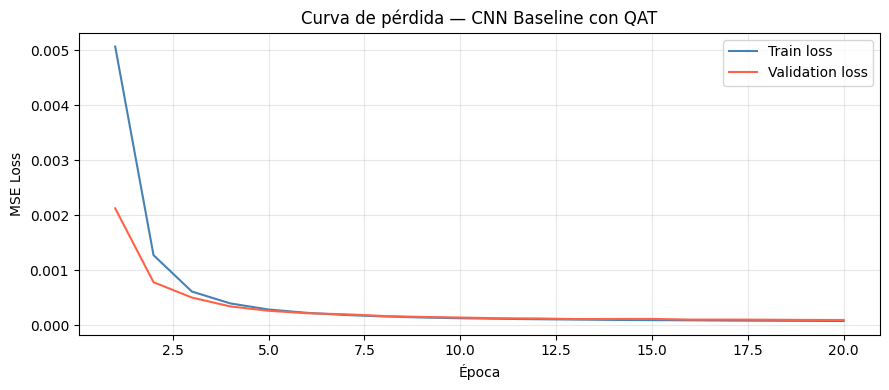

In [4]:
with open(LOSSES_PATH, 'rb') as f:
    losses = pickle.load(f)

train_loss_key = 'train_losses' if 'train_losses' in losses else 'train'
val_loss_key   = 'val_losses' if 'val_losses' in losses else 'val'

epochs = range(1, len(losses[train_loss_key]) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, losses[train_loss_key], label='Train loss',      color='steelblue')
ax.plot(epochs, losses[val_loss_key],   label='Validation loss', color='tomato')
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de pérdida — CNN Baseline con QAT')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. RMSE en píxeles

C:\Users\perec\AppData\Local\Temp\ipykernel_15432\1319270877.py:85: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  img = torch.from_numpy(np.ascontiguousarray(self.images_mm[j],    dtype=np.float32))


RMSE global:            1.07 px
RMSE mínimo (keypoint): 0.89 px  (kp #42)
RMSE máximo (keypoint): 1.39 px  (kp #16)


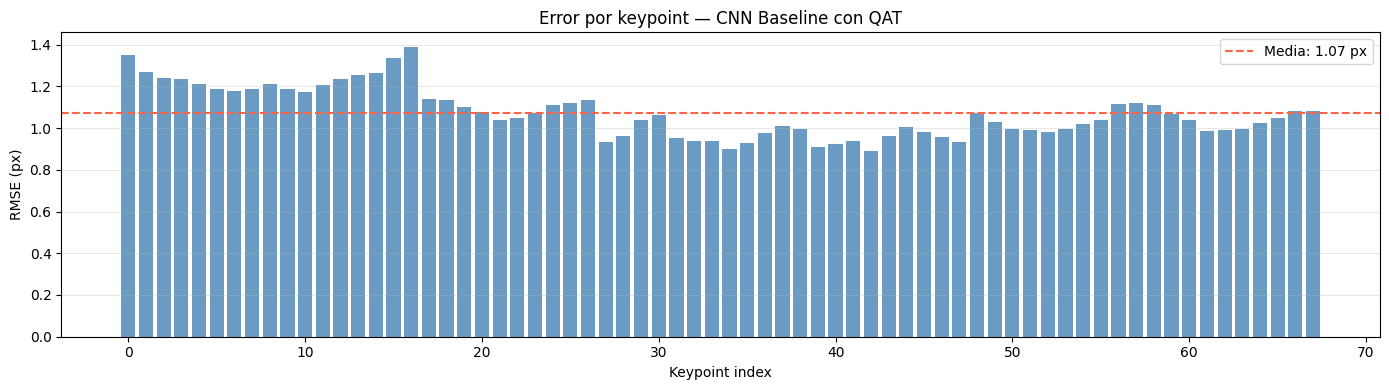

In [5]:
model.eval()
all_gt, all_pred = [], []

with torch.no_grad():
    for imgs, kps in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).cpu().numpy()
        all_gt.append(kps.numpy())
        all_pred.append(preds)

all_gt   = np.concatenate(all_gt,   axis=0) * IMG_SIZE
all_pred = np.concatenate(all_pred, axis=0) * IMG_SIZE

diff    = (all_gt - all_pred).reshape(-1, 68, 2)
dist_px = np.sqrt((diff ** 2).sum(axis=2))

rmse_per_kp  = dist_px.mean(axis=0)
rmse_overall = dist_px.mean()

print(f'RMSE global:            {rmse_overall:.2f} px')
print(f'RMSE mínimo (keypoint): {rmse_per_kp.min():.2f} px  (kp #{rmse_per_kp.argmin()})')
print(f'RMSE máximo (keypoint): {rmse_per_kp.max():.2f} px  (kp #{rmse_per_kp.argmax()})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(68), rmse_per_kp, color='steelblue', alpha=0.8)
ax.axhline(rmse_overall, color='tomato', linestyle='--', label=f'Media: {rmse_overall:.2f} px')
ax.set_xlabel('Keypoint index'); ax.set_ylabel('RMSE (px)')
ax.set_title('Error por keypoint — CNN Baseline con QAT')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 5.1 Percentiles del RMSE (p50, p90, p99).

In [6]:

rmse_per_frame = np.sqrt((dist_px ** 2).mean(axis=1))   

p50 = np.percentile(rmse_per_frame, 50)  
p90 = np.percentile(rmse_per_frame, 90)
p99 = np.percentile(rmse_per_frame, 99)

print('RMSE por frame — estadisticos:')
print(f'  media : {rmse_per_frame.mean():.3f} px')
print(f'  std   : {rmse_per_frame.std():.3f} px')
print(f'  min   : {rmse_per_frame.min():.3f} px')
print(f'  max   : {rmse_per_frame.max():.3f} px')
print()
print('Percentiles del RMSE:')
print(f'  p50 (mediana): {p50:.3f} px')
print(f'  p90          : {p90:.3f} px')
print(f'  p99          : {p99:.3f} px')

RMSE por frame — estadisticos:
  media : 1.209 px
  std   : 0.506 px
  min   : 0.621 px
  max   : 19.856 px

Percentiles del RMSE:
  p50 (mediana): 1.099 px
  p90          : 1.651 px
  p99          : 2.907 px


## 5.2 Distribución del RMSE

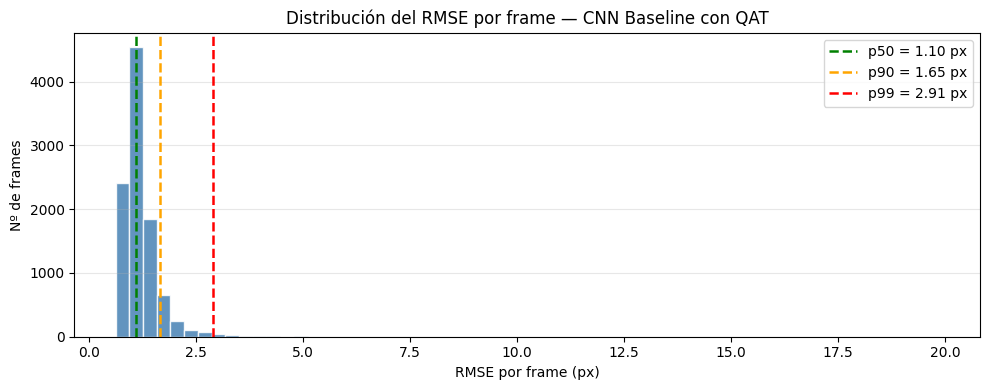

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rmse_per_frame, bins=60, color='steelblue', alpha=0.85, edgecolor='white')
for val, col, lab in [(p50, 'green', 'p50'), (p90, 'orange', 'p90'), (p99, 'red', 'p99')]:
    ax.axvline(val, color=col, linestyle='--', linewidth=1.8, label=f'{lab} = {val:.2f} px')
ax.set_xlabel('RMSE por frame (px)'); ax.set_ylabel('Nº de frames')
ax.set_title('Distribución del RMSE por frame — CNN Baseline con QAT')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5.3 Los 5 mejores y los 5 peores frames

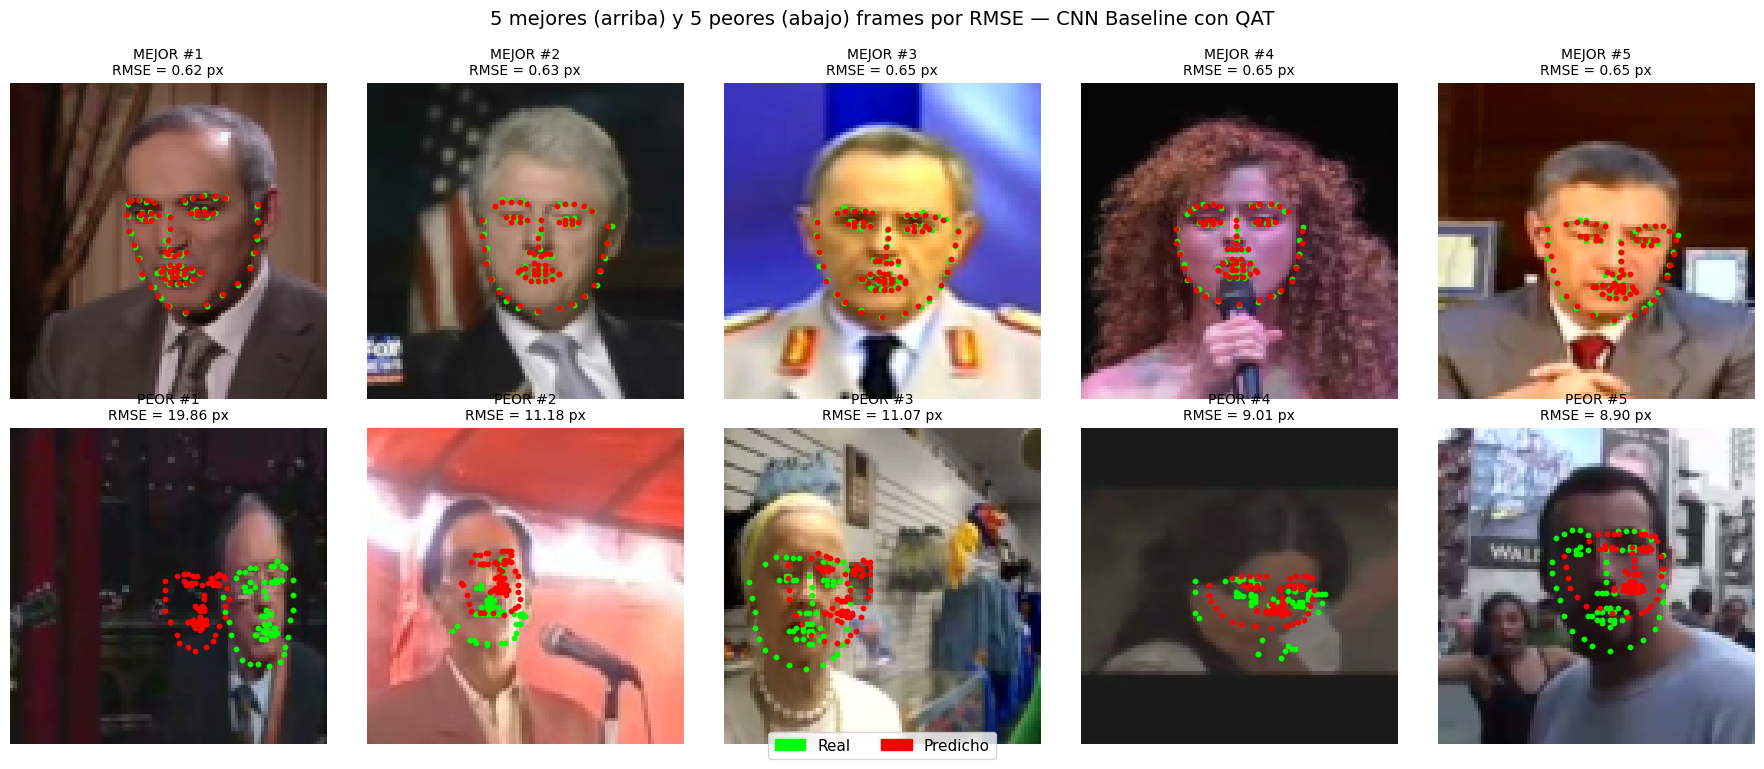

In [8]:
# Ordenar frames por RMSE: los 5 mejores (menor error) y los 5 peores (mayor error)
order     = np.argsort(rmse_per_frame)
best_idx  = order[:5]
worst_idx = order[-5:][::-1]   # peor primero

def _plot_frame(ax, i, title_prefix):
    img  = val_dataset[i][0].numpy().transpose(1, 2, 0)   # (H, W, 3)
    gt   = all_gt[i].reshape(-1, 2)     # ya en pixeles
    pred = all_pred[i].reshape(-1, 2)   # ya en pixeles
    ax.imshow(np.clip(img, 0, 1))
    ax.scatter(gt[:, 0],   gt[:, 1],   s=10, c='lime', zorder=5)
    ax.scatter(pred[:, 0], pred[:, 1], s=10, c='red',  zorder=6)
    ax.set_title(f'{title_prefix}\nRMSE = {rmse_per_frame[i]:.2f} px', fontsize=10)
    ax.axis('off')

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col, i in enumerate(best_idx):
    _plot_frame(axes[0, col], i, f'MEJOR #{col + 1}')
for col, i in enumerate(worst_idx):
    _plot_frame(axes[1, col], i, f'PEOR #{col + 1}')

patch_gt   = mpatches.Patch(color='lime', label='Real')
patch_pred = mpatches.Patch(color='red',  label='Predicho')
fig.legend(handles=[patch_gt, patch_pred], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.suptitle('5 mejores (arriba) y 5 peores (abajo) frames por RMSE — CNN Baseline con QAT',
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

## 5.4 Estadísticas adicionales

In [9]:

print('Fracción de frames con RMSE por debajo de un umbral:')
for thr in [0.5, 1.0, 1.5, 2.0, 3.0]:
    pct = (rmse_per_frame <= thr).mean() * 100
    print(f'  <= {thr:>3.1f} px : {pct:5.1f} %')


all_dist = dist_px.reshape(-1)
print()
print('Percentiles del error por keypoint individual (px):')
for q in [50, 90, 99]:
    print(f'  p{q}: {np.percentile(all_dist, q):.3f} px')


worst_kp = np.argsort(rmse_per_kp)[-5:][::-1]
print()
print('Top-5 keypoints mas dificiles (RMSE medio):')
for k in worst_kp:
    print(f'  kp #{k:>2d}: {rmse_per_kp[k]:.3f} px')

Fracción de frames con RMSE por debajo de un umbral:
  <= 0.5 px :   0.0 %
  <= 1.0 px :  34.2 %
  <= 1.5 px :  85.0 %
  <= 2.0 px :  95.7 %
  <= 3.0 px :  99.1 %

Percentiles del error por keypoint individual (px):
  p50: 0.945 px
  p90: 1.886 px
  p99: 3.432 px

Top-5 keypoints mas dificiles (RMSE medio):
  kp #16: 1.390 px
  kp # 0: 1.353 px
  kp #15: 1.335 px
  kp # 1: 1.270 px
  kp #14: 1.263 px


## 6. Resumen final

In [10]:
print('=' * 50)
print('RESUMEN FINAL — CNN Baseline con QAT')
print('=' * 50)
print(f'Frames usados:    50,000  (train: 40,000  val: 10,000)')
print(f'Épocas:           {len(losses[train_loss_key])}')
print(f'Mejor val MSE:    {min(losses[val_loss_key]):.6f}')
print(f'RMSE global:      {rmse_overall:.2f} px')
print(f'Modelo:           {MODEL_PATH}')


RESUMEN FINAL — CNN Baseline con QAT
Frames usados:    50,000  (train: 40,000  val: 10,000)
Épocas:           20
Mejor val MSE:    0.000093
RMSE global:      1.07 px
Modelo:           C:\Users\perec\Desktop\Deep_Learning\best_qat_cnn.pth
